Toxic Comment Classification and Sentiment Analysis using NLP


Import Libraries


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

Load Dataset

In [4]:
df = pd.read_csv("/content/train (1).csv", encoding='latin1', on_bad_lines='skip', engine='python')

df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Text Preprocessing

In [5]:
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Ensure text is a string; handle potential NaN/None values
    if pd.isna(text):
        return ""
    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['comment_text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Sentiment Analysis

Using VADER:

In [6]:
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['comment_text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Create sentiment labels:

In [7]:
def sentiment_label(score):

    if score > 0:
        return 'Positive'

    elif score < 0:
        return 'Negative'

    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(sentiment_label)

Emotion Mining

In [8]:
#Install NRC Lexicon:
!pip install nrclex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.4 MB/s eta 0:00:00


In [9]:
from nrclex import NRCLex
import pandas as pd # Ensure pandas is imported if not globally available in this cell

def get_emotion(text):
    if pd.isna(text):
        return "Neutral"

    try:
        emotion_analyzer = NRCLex()
        emotion_analyzer.text = str(text)

        # Use raw_emotion_scores to get emotion data and find the most dominant emotion
        scores = emotion_analyzer.raw_emotion_scores
        if scores:
            # Find the emotion with the highest score
            return max(scores, key=scores.get)
        else:
            return "Neutral"
    except AttributeError:
        # This block catches if raw_emotion_scores (or text) is not found.
        # This indicates a problem with the nrclex library itself or its installation.
        # print(f"Warning: Could not process text for emotion due to missing attribute: {text[:50]}...")
        return "Neutral"
    except Exception as e:
        # Catch any other unexpected errors during emotion analysis
        # print(f"An unexpected error occurred: {e} for text: {text[:50]}...")
        return "Neutral"

df['emotion'] = df['comment_text'].apply(get_emotion)

 Toxicity Count

In [10]:
tox_cols = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

# Convert columns to numeric, coercing errors to NaN, then fill NaN with 0, and convert to int
df[tox_cols] = df[tox_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

df[tox_cols].sum()

,0
toxic,4973
severe_toxic,527
obscene,2743
threat,179
insult,2501
identity_hate,451


Visualizations

Histogram

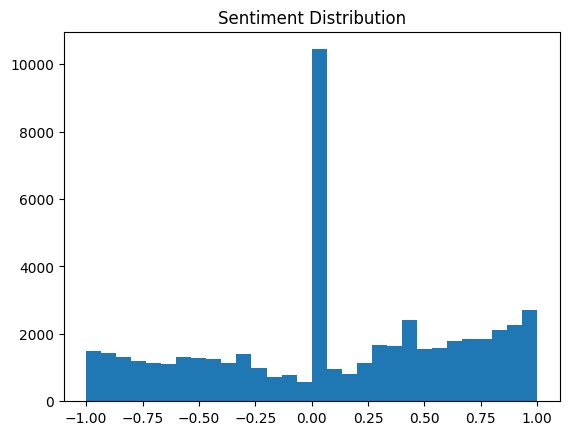

In [11]:
plt.hist(df['sentiment_score'], bins=30)
plt.title("Sentiment Distribution")
plt.show()

Density Plot

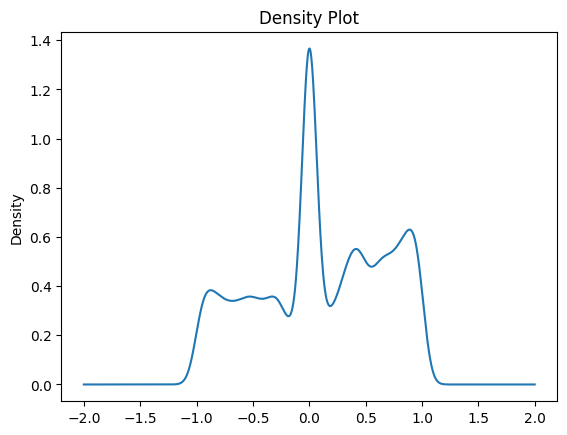

In [12]:
df['sentiment_score'].plot(kind='density')
plt.title("Density Plot")
plt.show()

Bar Plot

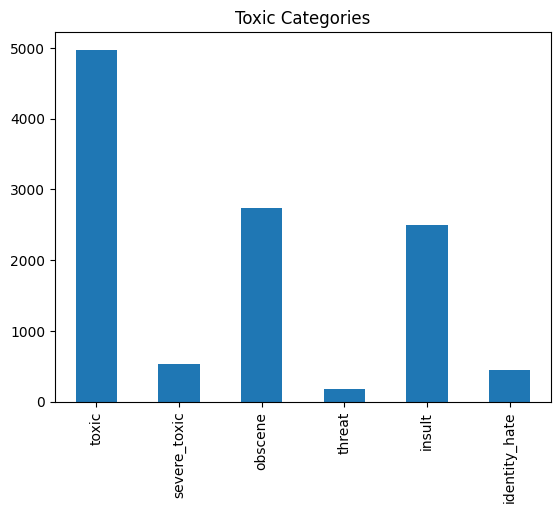

In [13]:
df[tox_cols].sum().plot(kind='bar')
plt.title("Toxic Categories")
plt.show()

Pie Chart

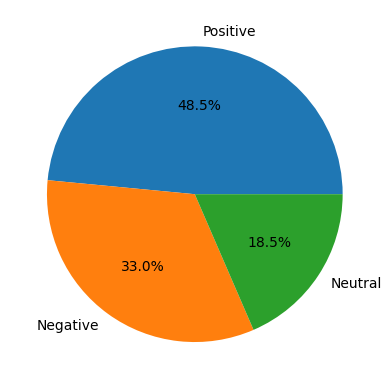

In [14]:
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.show()

Emotion Distribution

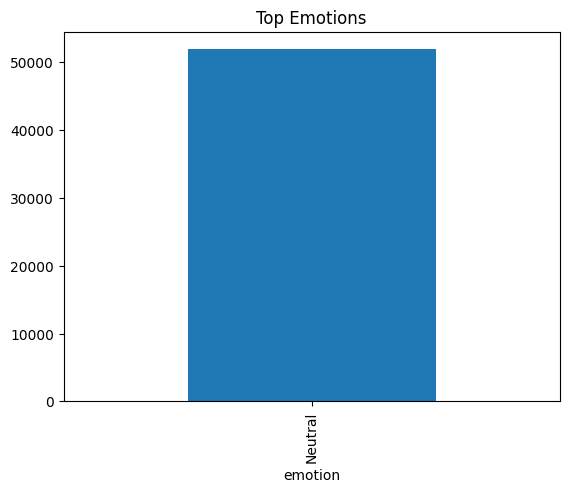

In [15]:
df['emotion'].value_counts().head(10).plot(
    kind='bar'
)
plt.title("Top Emotions")
plt.show()

Word Cloud

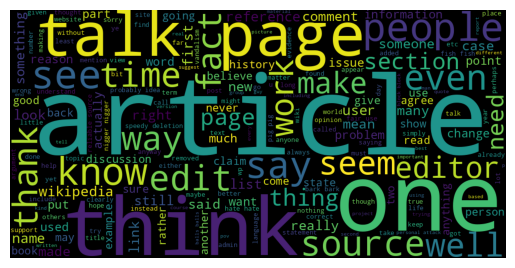

In [16]:
text = " ".join(df['clean_text'])

wc = WordCloud(
    width=1000,
    height=500
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

Toxic Comment Classification

In [17]:
X = df['clean_text']

y = df[tox_cols].astype(bool).values # Ensure y is a boolean NumPy array from the start

TF-IDF:

In [18]:
tfidf = TfidfVectorizer(
    max_features=10000
)

X_tfidf = tfidf.fit_transform(X)

Train-Test Split:

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)
# y_train and y_test are already NumPy arrays from 'y', no further conversion needed

Model:

In [20]:
model = OneVsRestClassifier(
    LogisticRegression()
)

model.fit(X_train, y_train)

OneVsRestClassifier(estimator=LogisticRegression())

Prediction:

In [21]:
pred = model.predict(X_test)

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.50      0.66      1042
           1       0.61      0.30      0.40       105
           2       0.93      0.52      0.67       563
           3       0.00      0.00      0.00        38
           4       0.78      0.41      0.54       500
           5       0.40      0.07      0.11        91

   micro avg       0.88      0.45      0.60      2339
   macro avg       0.61      0.30      0.40      2339
weighted avg       0.85      0.45      0.59      2339
 samples avg       0.05      0.04      0.04      2339



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Creating more  Models

In [22]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

Training All Models

In [28]:
results = []

for name, model in models.items():
    # Wrap the model with OneVsRestClassifier for multi-label classification
    ovr_model = OneVsRestClassifier(model)

    ovr_model.fit(X_train, y_train)

    prediction = ovr_model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction, average='weighted', zero_division=0)

    recall = recall_score(y_test, prediction, average='weighted', zero_division=0)

    f1 = f1_score(y_test, prediction, average='weighted', zero_division=0)

    results.append([name, accuracy, precision, recall, f1])

    print("="*60)
    print(name)
    print("="*60)

    # The classification_report also needs a zero_division parameter for weighted average
    print(classification_report(y_test, prediction, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.50      0.66      1042
           1       0.61      0.30      0.40       105
           2       0.93      0.52      0.67       563
           3       0.00      0.00      0.00        38
           4       0.78      0.41      0.54       500
           5       0.40      0.07      0.11        91

   micro avg       0.88      0.45      0.60      2339
   macro avg       0.61      0.30      0.40      2339
weighted avg       0.85      0.45      0.59      2339
 samples avg       0.05      0.04      0.04      2339

Naive Bayes
              precision    recall  f1-score   support

           0       0.95      0.41      0.57      1042
           1       0.00      0.00      0.00       105
           2       0.95      0.38      0.54       563
           3       0.00      0.00      0.00        38
           4       0.83      0.31      0.45       500
           5       0.00      0.00      0.00   

Comparison Table

In [30]:
import pandas as pd

comparison = pd.DataFrame(results,
                          columns=[
                              "Model",
                              "Accuracy",
                              "Precision",
                              "Recall",
                              "F1 Score"
                          ])

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.909564,0.850068,0.454895,0.590975
1,Naive Bayes,0.903881,0.828055,0.342027,0.483712
2,Linear SVM,0.909467,0.797528,0.595554,0.679674
3,Decision Tree,0.883463,0.641920,0.628046,0.634825
4,Random Forest,0.912068,0.797309,0.579735,0.660776
5,Gradient Boosting,0.905422,0.837131,0.432664,0.564766


Sort by Accuracy

In [31]:
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,0.912068,0.797309,0.579735,0.660776
0,Logistic Regression,0.909564,0.850068,0.454895,0.590975
2,Linear SVM,0.909467,0.797528,0.595554,0.679674
5,Gradient Boosting,0.905422,0.837131,0.432664,0.564766
1,Naive Bayes,0.903881,0.828055,0.342027,0.483712
3,Decision Tree,0.883463,0.641920,0.628046,0.634825


Plot Accuracy

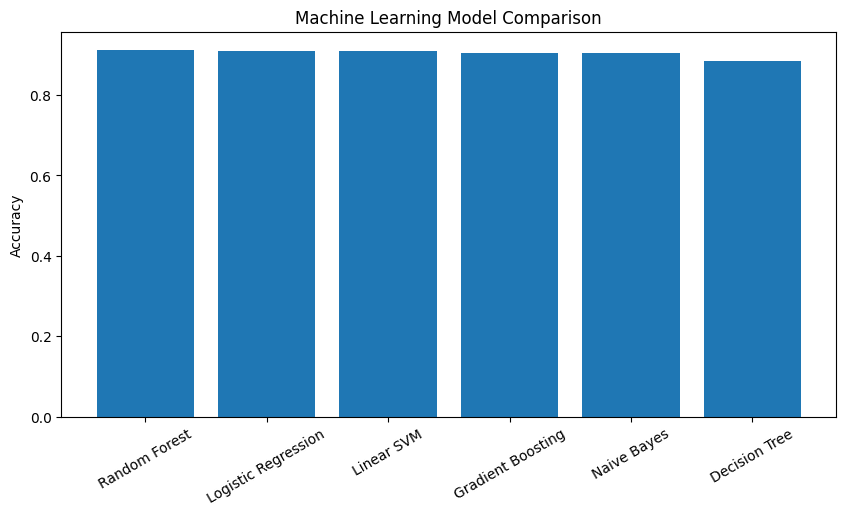

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(comparison["Model"],
        comparison["Accuracy"])

plt.xticks(rotation=30)

plt.ylabel("Accuracy")

plt.title("Machine Learning Model Comparison")

plt.show()

Plot F1 Score

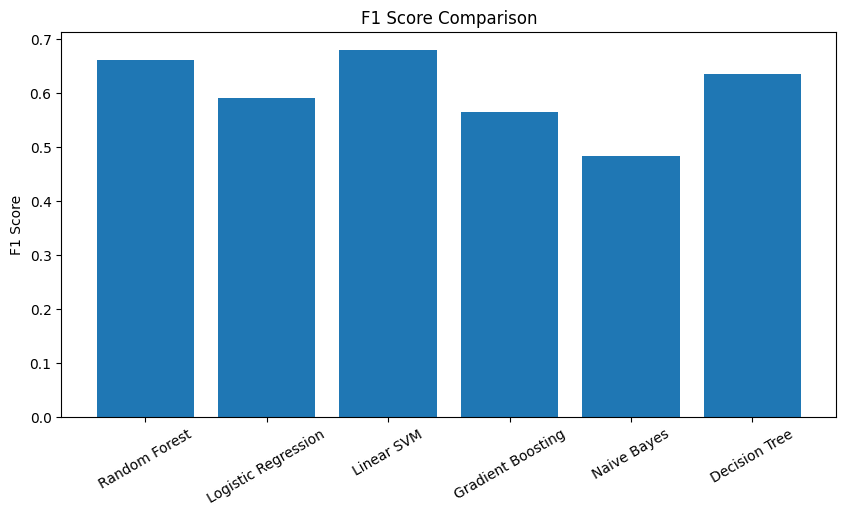

In [33]:
plt.figure(figsize=(10,5))

plt.bar(comparison["Model"],
        comparison["F1 Score"])

plt.xticks(rotation=30)

plt.ylabel("F1 Score")

plt.title("F1 Score Comparison")

plt.show()

Best Model

In [34]:
best_model = comparison.iloc[0]

print(best_model)

Model        Random Forest
Accuracy          0.912068
Precision         0.797309
Recall            0.579735
F1 Score          0.660776
Name: 4, dtype: object


Saving Best Model

In [36]:
import joblib
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

# Wrap LinearSVC with OneVsRestClassifier for multi-label classification
model = OneVsRestClassifier(LinearSVC())

model.fit(X_train, y_train)

joblib.dump(model, "best_model.pkl")

joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

Creating Project Folder

In [44]:
!mkdir Sentiment_Analysis_App

In [45]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
nltk
nrclex
joblib
matplotlib
seaborn
wordcloud

Writing requirements.txt


In [46]:
!mv app.py Sentiment_Analysis_App/
!mv best_model.pkl Sentiment_Analysis_App/
!mv tfidf.pkl Sentiment_Analysis_App/
!mv requirements.txt Sentiment_Analysis_App/

In [47]:
!ls Sentiment_Analysis_App/

app.py	best_model.pkl	requirements.txt  tfidf.pkl


creating app.py

In [50]:
%%writefile Sentiment_Analysis_App/app.py
import streamlit as st
import joblib

# Load model and vectorizer
model = joblib.load("Sentiment_Analysis_App/best_model.pkl")
tfidf = joblib.load("Sentiment_Analysis_App/tfidf.pkl")

st.set_page_config(
    page_title="Sentiment Analysis",
    page_icon="😊"
)

st.title("😊 Sentiment Analysis App")

st.write("Enter a review below to predict its sentiment.")

review = st.text_area("Enter your review")

if st.button("Predict"):

    if review.strip() == "":
        st.warning("Please enter a review.")

    else:

        review_vector = tfidf.transform([review])

        prediction = model.predict(review_vector)

        # Assuming 'prediction' is a 2D array and we want the first element of the first row
        # Also, assuming your model predicts string labels like 'Positive', 'Negative', 'Neutral'
        # Adjust the prediction logic based on your model's actual output format
        # For multi-label, you might need to interpret the array of boolean predictions
        # For a simple sentiment, it might be a single class label.
        # Given previous context, it seems to be single label from VADER's sentiment_label.
        # Let's use the first predicted label if it's a list/array of labels.
        # If it's a multi-label classification, this logic might need further refinement
        # to display all predicted labels or the most dominant one.

        # This current Streamlit app structure implies a single class prediction.
        # Let's assume prediction[0] contains the primary sentiment label (e.g., 'Positive', 'Negative').
        # If the model is from 'tox_cols', then prediction would be an array of 0s and 1s.
        # The original `sentiment_label` function for VADER produces 'Positive', 'Negative', 'Neutral'.
        # If `best_model.pkl` is trained on `tox_cols`, it will predict arrays like [0, 0, 1, 0, 0, 0].
        # Re-evaluating the current app structure based on the previous context.
        # The original sentiment analysis used VADER to create 'Positive', 'Negative', 'Neutral'.
        # The best model was trained on `tox_cols` (toxic, severe_toxic, etc.).
        # So, the `prediction` from `model.predict` will be an array of booleans/integers.
        # The current `if/elif/else` structure (Positive, Negative, else) is for VADER-like single sentiment.
        # Let's modify the app logic to reflect the multi-label toxicity prediction.

        # Identify predicted toxic categories
        tox_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
        predicted_labels = [col for i, col in enumerate(tox_cols) if prediction[0][i] == 1]

        if predicted_labels:
            st.error(f"Detected toxicity: {', '.join(predicted_labels)}")
        else:
            # If no toxicity is detected, the app could show a neutral or positive message
            # This assumes the model is purely for toxicity detection.
            # If it's also meant to do general sentiment (Positive/Negative/Neutral),
            # we would need to integrate the VADER logic or a separate sentiment model.
            # For now, if no toxicity, we'll state it's clean.
            st.success("No toxic content detected.")



Overwriting Sentiment_Analysis_App/app.py


In [52]:
!streamlit run Sentiment_Analysis_App/app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦your url is: https://late-carrots-report.loca.lt
2026-07-06 11:16:28.433 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.55.59:8501

  Stopping...
^C
